In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

B_RESULTS_CSV_PATH = "B_results.csv"

mu0 = 4 * np.pi * 1e-7  # T m / A

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"

B_df = pd.read_csv(B_RESULTS_CSV_PATH)

required_cols = [
    "row", "col", "x_um", "y_um",
    "Bx_pos_nT", "By_pos_nT", "Bz_pos_nT",
    "Bx_neg_nT", "By_neg_nT", "Bz_neg_nT",
]

missing = [c for c in required_cols if c not in B_df.columns]
if missing:
    raise ValueError(f"Missing columns in B_results.csv: {missing}")

B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_um),
    np.nanmax(x_um),
    np.nanmin(y_um),
    np.nanmax(y_um),
]

B_pos_nT = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_nT = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_odd_nT = 0.5 * (B_pos_nT - B_neg_nT)
B_even_nT = 0.5 * (B_pos_nT + B_neg_nT)

dx_um = np.nanmedian(np.diff(x_um[0, :]))
dy_um = np.nanmedian(np.diff(y_um[:, 0]))

dx_m = dx_um * 1e-6
dy_m = dy_um * 1e-6

print("Loaded measured data")
print("grid:", grid_size, "x", grid_size)
print("extent_um:", extent_um)
print("dx_um:", dx_um)
print("dy_um:", dy_um)

if "POS_time_actual_s" in B_df.columns:
    print("POS time [s]:", B_df["POS_time_actual_s"].iloc[0])
if "NEG_time_actual_s" in B_df.columns:
    print("NEG time [s]:", B_df["NEG_time_actual_s"].iloc[0])

Loaded measured data
grid: 31 x 31
extent_um: [np.float64(-100.0), np.float64(100.0), np.float64(-100.0), np.float64(100.0)]
dx_um: 6.666666666666671
dy_um: 6.666666666666671
POS time [s]: 0.0625968
NEG time [s]: 0.0571872


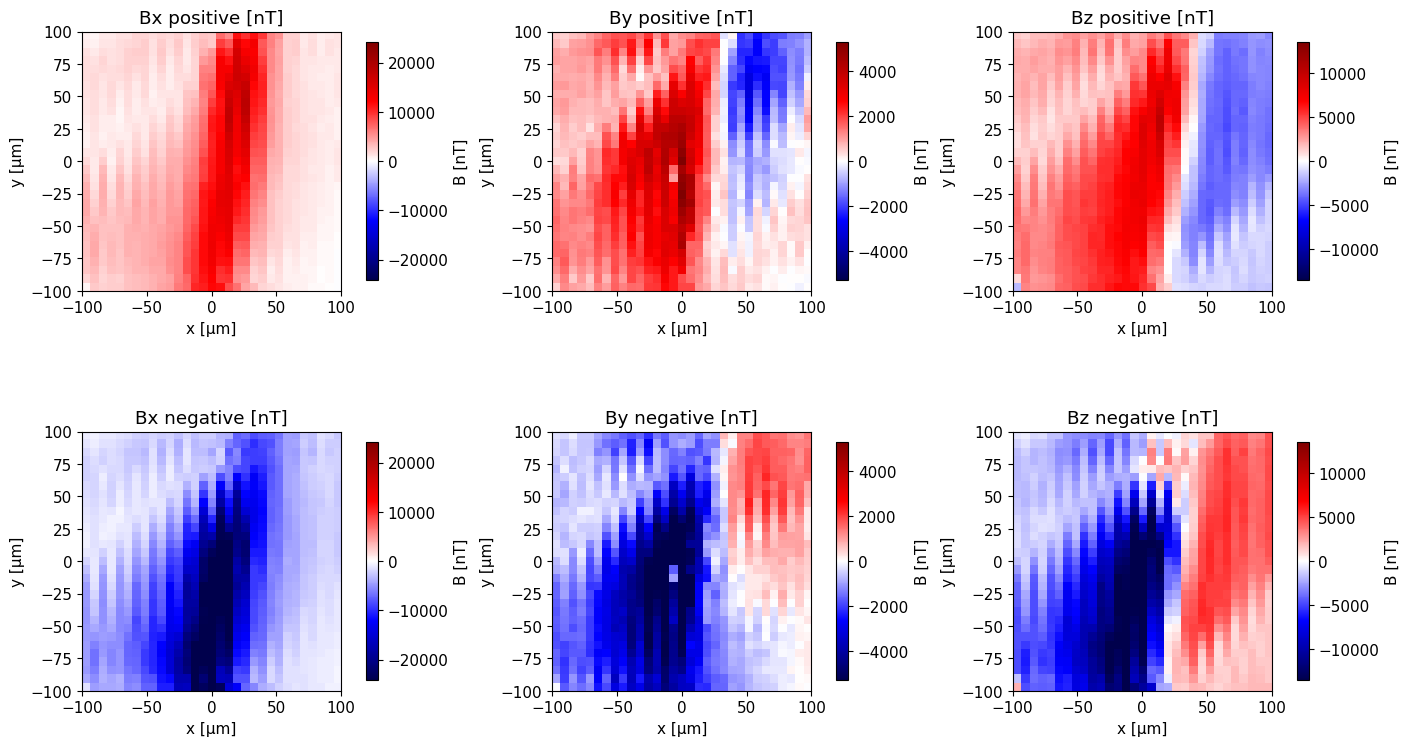

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_nT[i]), 95),
        np.nanpercentile(np.abs(B_neg_nT[i]), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_pos_nT[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"{comp} positive [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04).set_label("B [nT]")

    im1 = axes[1, i].imshow(
        B_neg_nT[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"{comp} negative [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04).set_label("B [nT]")

plt.show()

In [32]:
def reconstruct_current_from_Bz_only(
    Bz_nT,
    dx_m,
    dy_m,
    stand_off_um,
    k_filter_fraction=0.25,
):
    """
    Reconstruct divergence-free 2D sheet current Kx, Ky from Bz only.

    This is usually more stable as a first diagnostic than forcing
    Bx, By, and Bz to agree simultaneously.
    """

    Bz_T = Bz_nT * 1e-9
    ny, nx = Bz_T.shape

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx_m)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy_m)
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    h_m = stand_off_um * 1e-6

    # Remove DC offset before inversion
    Bz_T = Bz_T - np.nanmean(Bz_T)

    Bz_k = np.fft.fft2(Bz_T)

    K_safe = K.copy()
    K_safe[0, 0] = np.inf

    k_nyquist = np.pi / min(dx_m, dy_m)
    k_cut = k_filter_fraction * k_nyquist
    filt = np.exp(-(K / k_cut)**4)
    filt[0, 0] = 0.0

    # Stream function inversion:
    # Bz(k,h) = (mu0/2) k exp(-kh) g(k)
    g_k = 2.0 * np.exp(K * h_m) * Bz_k / (mu0 * K_safe)
    g_k = g_k * filt
    g_k[0, 0] = 0.0

    Kx_k = 1j * KY * g_k
    Ky_k = -1j * KX * g_k

    Kx = np.real(np.fft.ifft2(Kx_k))
    Ky = np.real(np.fft.ifft2(Ky_k))
    Kmag = np.sqrt(Kx**2 + Ky**2)

    return Kx, Ky, Kmag

Bz-only reconstruction
----------------------
Kx p95 [A/m]: 32.668983749652234
Ky p95 [A/m]: 83.76245707195382
|K| p95 [A/m]: 84.64540588642149


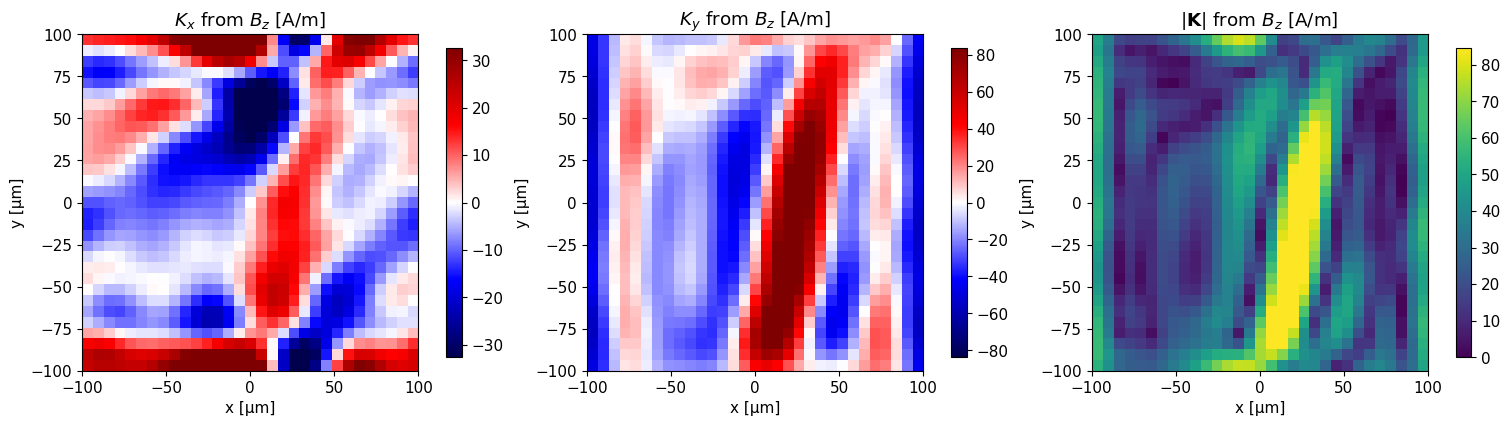

In [33]:
Bz_current_nT = B_odd_nT[2]

STAND_OFF_UM = 35.0
K_FILTER_FRACTION = 0.25

Kx_Bz_A_per_m, Ky_Bz_A_per_m, Kmag_Bz_A_per_m = reconstruct_current_from_Bz_only(
    Bz_nT=Bz_current_nT,
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
    k_filter_fraction=K_FILTER_FRACTION,
)

print("Bz-only reconstruction")
print("----------------------")
print("Kx p95 [A/m]:", np.nanpercentile(np.abs(Kx_Bz_A_per_m), 95))
print("Ky p95 [A/m]:", np.nanpercentile(np.abs(Ky_Bz_A_per_m), 95))
print("|K| p95 [A/m]:", np.nanpercentile(Kmag_Bz_A_per_m, 95))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

maps = [
    (Kx_Bz_A_per_m, r"$K_x$ from $B_z$ [A/m]", CMAP),
    (Ky_Bz_A_per_m, r"$K_y$ from $B_z$ [A/m]", CMAP),
    (Kmag_Bz_A_per_m, r"$|\mathbf{K}|$ from $B_z$ [A/m]", "viridis"),
]

for ax, (data, title, cmap) in zip(axes, maps):
    if "mathbf" in title:
        vmin = 0
        vmax = np.nanpercentile(data, 95)
    else:
        lim = np.nanpercentile(np.abs(data), 95)
        vmin = -lim
        vmax = lim

    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [34]:
# ============================================================
# Tilt-aware current estimate
# ============================================================
# The current is approximately along:
#   u = (sin(theta), cos(theta))
#
# So the parallel current-density component is:
#   K_parallel = Kx sin(theta) + Ky cos(theta)
#
# The perpendicular coordinate is:
#   s_perp = (x-x0) cos(theta) - (y-y0) sin(theta)
#
# Total current should be estimated by integrating K_parallel
# across s_perp, not by integrating Ky along horizontal rows.
# ============================================================

WIRE_THETA_DEG = 8.0
WIRE_X0_UM = 20.0
WIRE_Y0_UM = 0.0

theta = np.deg2rad(WIRE_THETA_DEG)

u_x = np.sin(theta)
u_y = np.cos(theta)

p_x = np.cos(theta)
p_y = -np.sin(theta)

K_parallel = Kx_Bz_A_per_m * u_x + Ky_Bz_A_per_m * u_y
K_perp = Kx_Bz_A_per_m * p_x + Ky_Bz_A_per_m * p_y

s_perp_um = (x_um - WIRE_X0_UM) * p_x + (y_um - WIRE_Y0_UM) * p_y
s_para_um = (x_um - WIRE_X0_UM) * u_x + (y_um - WIRE_Y0_UM) * u_y

print("K_parallel p95 [A/m]:", np.nanpercentile(np.abs(K_parallel), 95))
print("K_perp p95 [A/m]:", np.nanpercentile(np.abs(K_perp), 95))
print("ratio K_parallel/K_perp:",
      np.nanpercentile(np.abs(K_parallel), 95) / np.nanpercentile(np.abs(K_perp), 95))

K_parallel p95 [A/m]: 84.26919166178806
K_perp p95 [A/m]: 31.35703339132611
ratio K_parallel/K_perp: 2.687409571247845


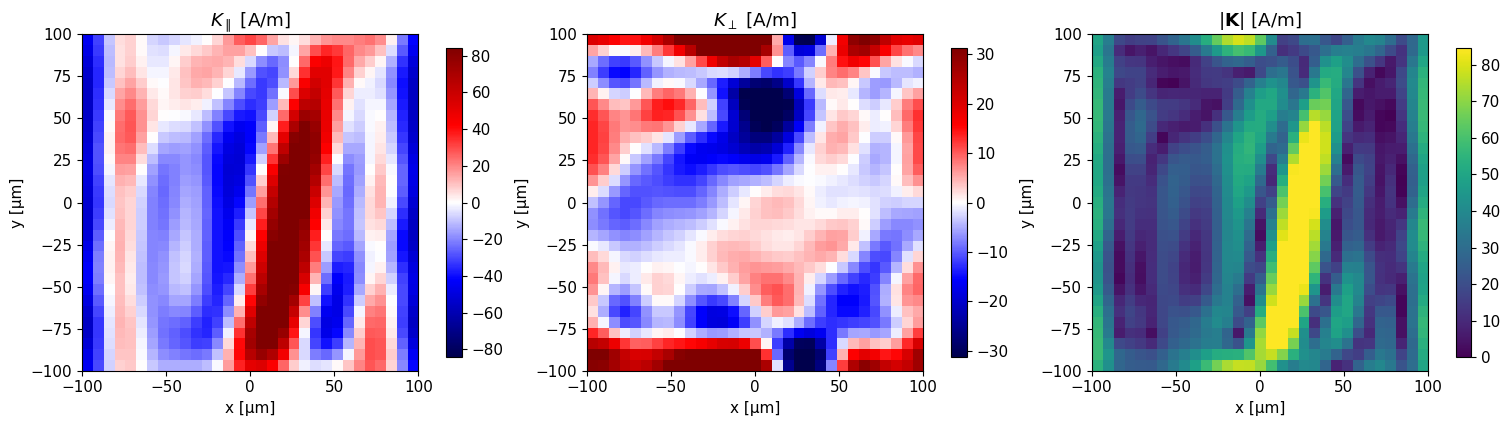

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

maps = [
    (K_parallel, r"$K_{\parallel}$ [A/m]", "seismic"),
    (K_perp, r"$K_{\perp}$ [A/m]", "seismic"),
    (np.sqrt(K_parallel**2 + K_perp**2), r"$|\mathbf{K}|$ [A/m]", "viridis"),
]

for ax, (data, title, cmap) in zip(axes, maps):
    if "mathbf" in title:
        vmin = 0
        vmax = np.nanpercentile(data, 95)
    else:
        lim = np.nanpercentile(np.abs(data), 95)
        vmin = -lim
        vmax = lim

    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

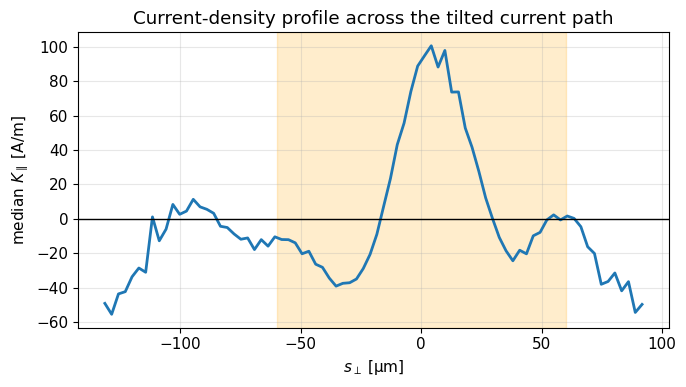

Tilt-aware current estimate
---------------------------
Integration half-width [µm]: 60.0
I_est_mA: 1.3493286394060044
Expected order: ~10 mA, but finite FOV and filtering can easily shift this.


In [36]:
# ============================================================
# Estimate total current by integrating across the wire
# ============================================================
# We bin K_parallel by the perpendicular coordinate s_perp.
# Then integrate the average K_parallel profile over s_perp.
# ============================================================

s = s_perp_um.ravel()
kp = K_parallel.ravel()

mask = np.isfinite(s) & np.isfinite(kp)

s = s[mask]
kp = kp[mask]

# Bin perpendicular coordinate.
n_bins = 80
bins = np.linspace(np.nanmin(s), np.nanmax(s), n_bins + 1)
centers = 0.5 * (bins[:-1] + bins[1:])

kp_profile = np.full(n_bins, np.nan)

for i in range(n_bins):
    m = (s >= bins[i]) & (s < bins[i + 1])
    if np.sum(m) > 0:
        kp_profile[i] = np.nanmedian(kp[m])

# Choose integration window around current ridge.
# Start with +/- 60 µm around s_perp = 0.
CURRENT_HALF_WIDTH_UM = 60.0
window = np.abs(centers) <= CURRENT_HALF_WIDTH_UM

I_est_A = np.trapezoid(kp_profile[window], x=centers[window] * 1e-6)
I_est_mA = 1e3 * I_est_A

plt.figure(figsize=(7, 4))
plt.plot(centers, kp_profile, lw=2)
plt.axvspan(-CURRENT_HALF_WIDTH_UM, CURRENT_HALF_WIDTH_UM, color="orange", alpha=0.2)
plt.axhline(0, color="black", lw=1)
plt.xlabel(r"$s_\perp$ [µm]")
plt.ylabel(r"median $K_{\parallel}$ [A/m]")
plt.title("Current-density profile across the tilted current path")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Tilt-aware current estimate")
print("---------------------------")
print("Integration half-width [µm]:", CURRENT_HALF_WIDTH_UM)
print("I_est_mA:", I_est_mA)
print("Expected order: ~10 mA, but finite FOV and filtering can easily shift this.")

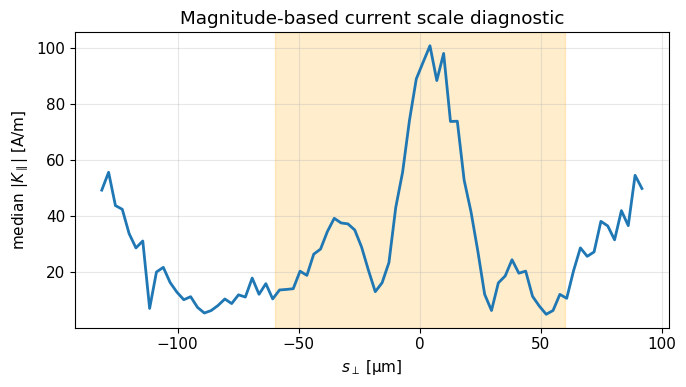

Magnitude-based current scale [mA]: 4.184888561300851


In [37]:
# ============================================================
# Magnitude-based current scale diagnostic
# ============================================================
# This does not give signed net current.
# It estimates the current scale from |K_parallel|.
# ============================================================

kp_abs_profile = np.full(n_bins, np.nan)

for i in range(n_bins):
    m = (s >= bins[i]) & (s < bins[i + 1])
    if np.sum(m) > 0:
        kp_abs_profile[i] = np.nanmedian(np.abs(kp[m]))

I_abs_A = np.trapezoid(kp_abs_profile[window], x=centers[window] * 1e-6)
I_abs_mA = 1e3 * I_abs_A

plt.figure(figsize=(7, 4))
plt.plot(centers, kp_abs_profile, lw=2)
plt.axvspan(-CURRENT_HALF_WIDTH_UM, CURRENT_HALF_WIDTH_UM, color="orange", alpha=0.2)
plt.xlabel(r"$s_\perp$ [µm]")
plt.ylabel(r"median $|K_{\parallel}|$ [A/m]")
plt.title("Magnitude-based current scale diagnostic")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Magnitude-based current scale [mA]:", I_abs_mA)

In [38]:
# ============================================================
# Sensitivity scan for Bz-only current reconstruction
# ============================================================

stand_off_values_um = [25, 35, 50, 75, 100]
filter_values = [0.20, 0.25, 0.35, 0.45]

rows = []

for h_um in stand_off_values_um:
    for filt_frac in filter_values:
        Kx_tmp, Ky_tmp, Kmag_tmp = reconstruct_current_from_Bz_only(
            Bz_nT=Bz_current_nT,
            dx_m=dx_m,
            dy_m=dy_m,
            stand_off_um=h_um,
            k_filter_fraction=filt_frac,
        )

        theta = np.deg2rad(WIRE_THETA_DEG)
        u_x = np.sin(theta)
        u_y = np.cos(theta)
        p_x = np.cos(theta)
        p_y = -np.sin(theta)

        Kpar_tmp = Kx_tmp * u_x + Ky_tmp * u_y

        s_tmp = ((x_um - WIRE_X0_UM) * p_x + (y_um - WIRE_Y0_UM) * p_y).ravel()
        kp_tmp = Kpar_tmp.ravel()

        mask = np.isfinite(s_tmp) & np.isfinite(kp_tmp)
        s = s_tmp[mask]
        kp = kp_tmp[mask]

        n_bins = 80
        bins = np.linspace(np.nanmin(s), np.nanmax(s), n_bins + 1)
        centers = 0.5 * (bins[:-1] + bins[1:])

        kp_profile = np.full(n_bins, np.nan)
        kp_abs_profile = np.full(n_bins, np.nan)

        for i in range(n_bins):
            m = (s >= bins[i]) & (s < bins[i + 1])
            if np.sum(m) > 0:
                kp_profile[i] = np.nanmedian(kp[m])
                kp_abs_profile[i] = np.nanmedian(np.abs(kp[m]))

        CURRENT_HALF_WIDTH_UM = 60.0
        window = np.abs(centers) <= CURRENT_HALF_WIDTH_UM

        I_signed_mA = 1e3 * np.trapezoid(
            kp_profile[window],
            x=centers[window] * 1e-6,
        )

        I_abs_mA = 1e3 * np.trapezoid(
            kp_abs_profile[window],
            x=centers[window] * 1e-6,
        )

        rows.append({
            "stand_off_um": h_um,
            "k_filter_fraction": filt_frac,
            "Kx_p95_A_per_m": np.nanpercentile(np.abs(Kx_tmp), 95),
            "Ky_p95_A_per_m": np.nanpercentile(np.abs(Ky_tmp), 95),
            "Kmag_p95_A_per_m": np.nanpercentile(Kmag_tmp, 95),
            "I_signed_mA": I_signed_mA,
            "I_abs_mA": I_abs_mA,
        })

sensitivity_df = pd.DataFrame(rows)
display(sensitivity_df)

,stand_off_um,k_filter_fraction,Kx_p95_A_per_m,Ky_p95_A_per_m,Kmag_p95_A_per_m,I_signed_mA,I_abs_mA
0,25,0.20,1.509359e+01,3.683524e+01,3.709754e+01,9.763979e-01,2.008719e+00
1,25,0.25,1.628704e+01,4.418957e+01,4.447538e+01,1.037853e+00,2.204843e+00
2,25,0.35,2.404715e+01,5.907836e+01,6.143495e+01,9.796256e-01,2.595951e+00
3,25,0.45,6.563690e+01,1.283072e+02,1.356397e+02,8.732659e-01,2.996219e+00
4,35,0.20,2.593323e+01,6.317680e+01,6.382807e+01,1.303951e+00,3.465732e+00
5,35,0.25,3.266898e+01,8.376246e+01,8.464541e+01,1.349329e+00,4.184889e+00
6,35,0.35,1.008854e+02,2.150755e+02,2.262798e+02,1.020785e+00,5.991306e+00
7,35,0.45,7.185741e+02,1.113854e+03,1.246213e+03,1.601596e+00,1.461369e+01
8,50,0.20,6.672810e+01,1.603670e+02,1.634489e+02,1.635483e+00,9.234540e+00
9,50,0.25,1.397047e+02,2.721094e+02,2.942600e+02,1.804410e+00,1.570755e+01


Forward-check result
--------------------
STAND_OFF_UM: 35.0
Bz measured p95 [nT]: 8228.138063102457
Bz forward p95  [nT]: 7922.456265466718
Bz residual p95 [nT]: 2287.4191086175197
Bz residual RMS [nT]: 1071.6233833008373
corr(measured Bz, forward Bz): 0.9728812581205372


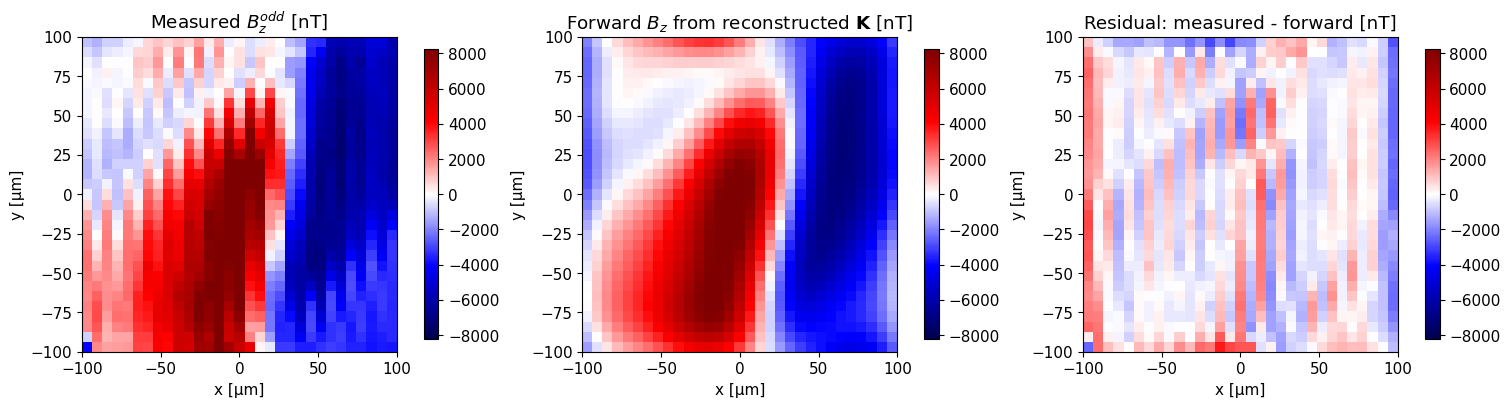

In [39]:
# ============================================================
# Forward check:
# Calculate B from reconstructed sheet current Kx, Ky
# ============================================================
# Purpose:
#   Check whether the reconstructed current actually reproduces
#   the measured current-generated Bz map.
#
# Input:
#   Kx_Bz_A_per_m, Ky_Bz_A_per_m  [A/m]
#   stand-off distance             [µm]
#
# Output:
#   Bx_forward_nT, By_forward_nT, Bz_forward_nT
#
# Model:
#   Thin 2D sheet current at z = 0,
#   magnetic field measured at height h.
# ============================================================

def forward_B_from_sheet_current(
    Kx_A_per_m,
    Ky_A_per_m,
    dx_m,
    dy_m,
    stand_off_um,
):
    """
    Forward-calculate Bx, By, Bz from a 2D sheet current Kx, Ky.

    Units:
        Kx, Ky : A/m
        dx, dy : m
        h      : µm
        output : nT
    """

    ny, nx = Kx_A_per_m.shape

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx_m)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy_m)

    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    h_m = stand_off_um * 1e-6

    Kx_k = np.fft.fft2(Kx_A_per_m)
    Ky_k = np.fft.fft2(Ky_A_per_m)

    decay = np.exp(-K * h_m)

    K_safe = K.copy()
    K_safe[0, 0] = np.inf

    # Fourier-space sheet-current magnetic field.
    Bx_k = -0.5 * mu0 * decay * Ky_k
    By_k =  0.5 * mu0 * decay * Kx_k

    Bz_k = (
        0.5 * mu0
        * decay
        * (1j / K_safe)
        * (KX * Ky_k - KY * Kx_k)
    )

    # The k=0 component of Bz is not determined by current inversion.
    Bz_k[0, 0] = 0.0

    Bx_T = np.real(np.fft.ifft2(Bx_k))
    By_T = np.real(np.fft.ifft2(By_k))
    Bz_T = np.real(np.fft.ifft2(Bz_k))

    return 1e9 * Bx_T, 1e9 * By_T, 1e9 * Bz_T


Bx_forward_nT, By_forward_nT, Bz_forward_nT = forward_B_from_sheet_current(
    Kx_A_per_m=Kx_Bz_A_per_m,
    Ky_A_per_m=Ky_Bz_A_per_m,
    dx_m=dx_m,
    dy_m=dy_m,
    stand_off_um=STAND_OFF_UM,
)

# Remove DC offset from measured Bz because the Fourier current inversion
# cannot reconstruct the spatially uniform Bz component.
Bz_measured_for_check_nT = Bz_current_nT - np.nanmean(Bz_current_nT)
Bz_forward_for_check_nT = Bz_forward_nT - np.nanmean(Bz_forward_nT)

residual_Bz_nT = Bz_measured_for_check_nT - Bz_forward_for_check_nT

mask = np.isfinite(Bz_measured_for_check_nT) & np.isfinite(Bz_forward_for_check_nT)

corr_Bz = np.corrcoef(
    Bz_measured_for_check_nT[mask].ravel(),
    Bz_forward_for_check_nT[mask].ravel(),
)[0, 1]

rms_Bz_nT = np.sqrt(np.nanmean(residual_Bz_nT[mask] ** 2))

p95_meas = np.nanpercentile(np.abs(Bz_measured_for_check_nT), 95)
p95_forward = np.nanpercentile(np.abs(Bz_forward_for_check_nT), 95)
p95_residual = np.nanpercentile(np.abs(residual_Bz_nT), 95)

print("Forward-check result")
print("--------------------")
print("STAND_OFF_UM:", STAND_OFF_UM)
print("Bz measured p95 [nT]:", p95_meas)
print("Bz forward p95  [nT]:", p95_forward)
print("Bz residual p95 [nT]:", p95_residual)
print("Bz residual RMS [nT]:", rms_Bz_nT)
print("corr(measured Bz, forward Bz):", corr_Bz)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

lim = max(
    np.nanpercentile(np.abs(Bz_measured_for_check_nT), 95),
    np.nanpercentile(np.abs(Bz_forward_for_check_nT), 95),
    np.nanpercentile(np.abs(residual_Bz_nT), 95),
)

if lim == 0 or not np.isfinite(lim):
    lim = 1.0

maps = [
    (Bz_measured_for_check_nT, r"Measured $B_z^{odd}$ [nT]"),
    (Bz_forward_for_check_nT, r"Forward $B_z$ from reconstructed $\mathbf{K}$ [nT]"),
    (residual_Bz_nT, r"Residual: measured - forward [nT]"),
]

for ax, (data, title) in zip(axes, maps):
    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap="seismic",
        vmin=-lim,
        vmax=lim,
    )
    ax.set_title(title)
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()